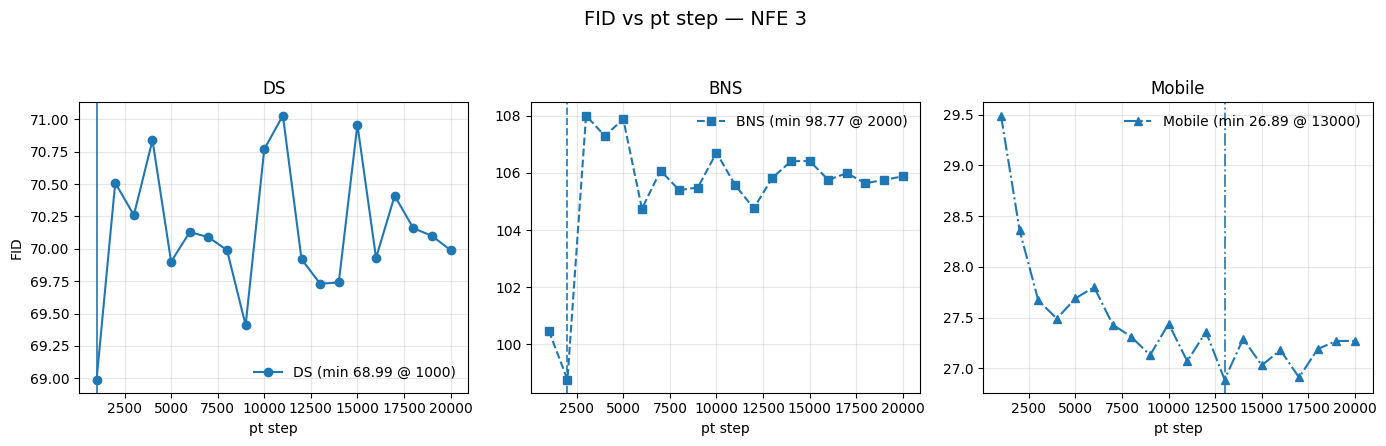

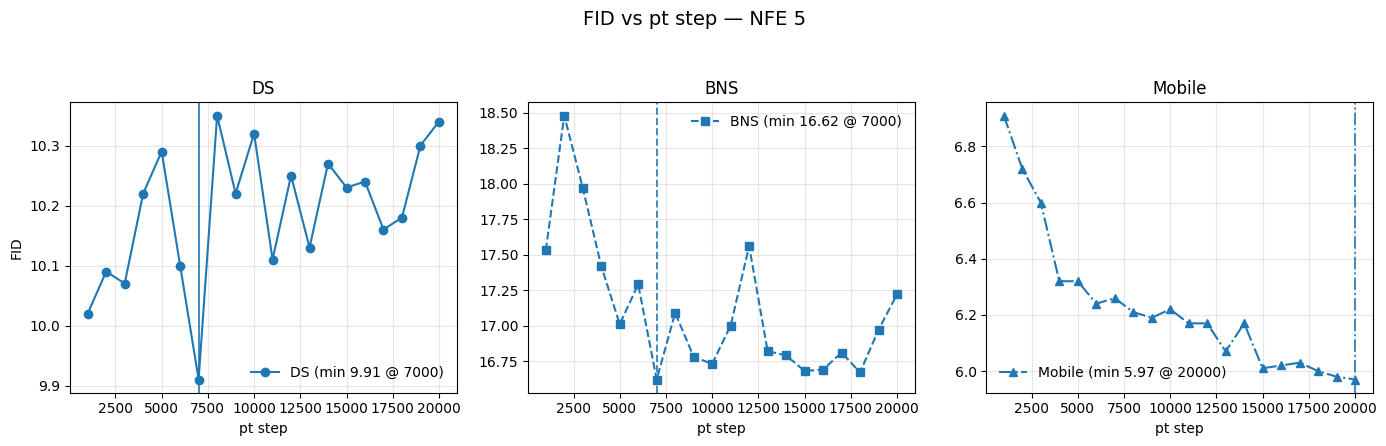

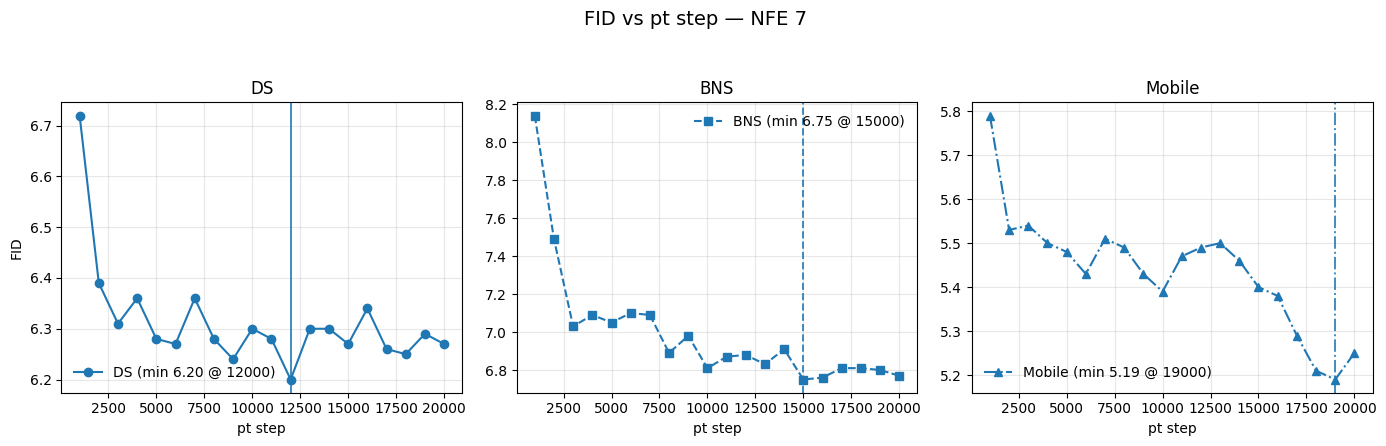

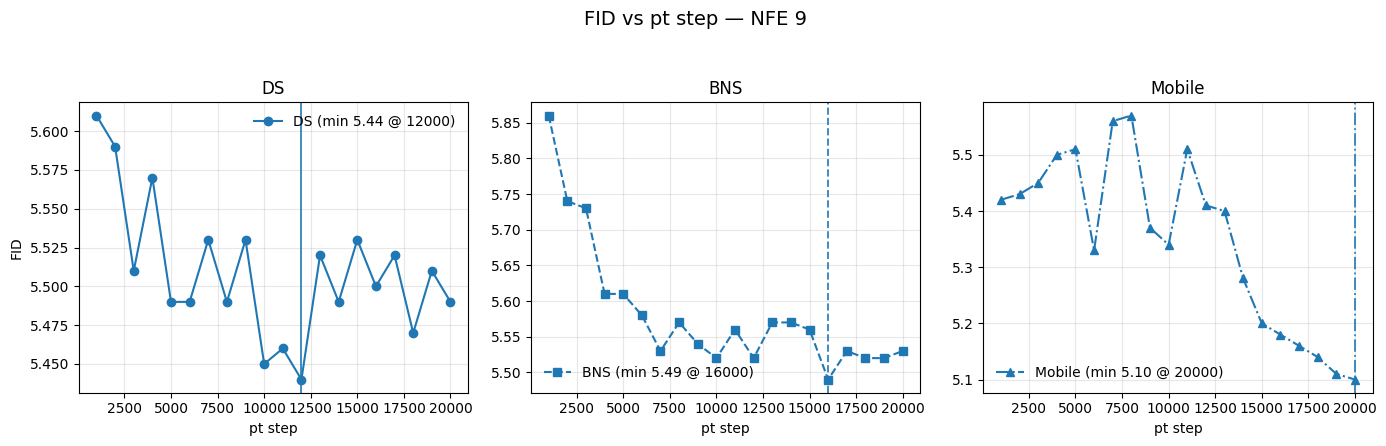

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Data ----------
steps = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000,
         11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000]

ds = {
    3: [68.99, 70.51, 70.26, 70.84, 69.90, 70.13, 70.09, 69.99, 69.41, 70.77,
        71.03, 69.92, 69.73, 69.74, 70.96, 69.93, 70.41, 70.16, 70.10, 69.99],
    5: [10.02, 10.09, 10.07, 10.22, 10.29, 10.10,  9.91, 10.35, 10.22, 10.32,
        10.11, 10.25, 10.13, 10.27, 10.23, 10.24, 10.16, 10.18, 10.30, 10.34],
    7: [ 6.72,  6.39,  6.31,  6.36,  6.28,  6.27,  6.36,  6.28,  6.24,  6.30,
         6.28,  6.20,  6.30,  6.30,  6.27,  6.34,  6.26,  6.25,  6.29,  6.27],
    9: [ 5.61,  5.59,  5.51,  5.57,  5.49,  5.49,  5.53,  5.49,  5.53,  5.45,
         5.46,  5.44,  5.52,  5.49,  5.53,  5.50,  5.52,  5.47,  5.51,  5.49],
}
bns = {
    3: [100.48,  98.77, 108.01, 107.30, 107.88, 104.75, 106.08, 105.40, 105.49, 106.71,
        105.58, 104.76, 105.83, 106.41, 106.42, 105.76, 105.99, 105.64, 105.76, 105.88],
    5: [ 17.53,  18.48,  17.97,  17.42,  17.01,  17.29,  16.62,  17.09,  16.78,  16.73,
         17.00,  17.56,  16.82,  16.79,  16.68,  16.69,  16.81,  16.67,  16.97,  17.22],
    7: [  8.14,   7.49,   7.03,   7.09,   7.05,   7.10,   7.09,   6.89,   6.98,   6.81,
          6.87,   6.88,   6.83,   6.91,   6.75,   6.76,   6.81,   6.81,   6.80,   6.77],
    9: [  5.86,   5.74,   5.73,   5.61,   5.61,   5.58,   5.53,   5.57,   5.54,   5.52,
          5.56,   5.52,   5.57,   5.57,   5.56,   5.49,   5.53,   5.52,   5.52,   5.53],
}
mobile = {
    3: [29.49, 28.36, 27.67, 27.49, 27.69, 27.80, 27.43, 27.31, 27.13, 27.44,
        27.07, 27.36, 26.89, 27.29, 27.03, 27.18, 26.91, 27.19, 27.27, 27.27],
    5: [ 6.91,  6.72,  6.60,  6.32,  6.32,  6.24,  6.26,  6.21,  6.19,  6.22,
          6.17,  6.17,  6.07,  6.17,  6.01,  6.02,  6.03,  6.00,  5.98,  5.97],
    7: [ 5.79,  5.53,  5.54,  5.50,  5.48,  5.43,  5.51,  5.49,  5.43,  5.39,
          5.47,  5.49,  5.50,  5.46,  5.40,  5.38,  5.29,  5.21,  5.19,  5.25],
    9: [ 5.42,  5.43,  5.45,  5.50,  5.51,  5.33,  5.56,  5.57,  5.37,  5.34,
          5.51,  5.41,  5.40,  5.28,  5.20,  5.18,  5.16,  5.14,  5.11,  5.10],
}

series = {"DS": ds, "BNS": bns, "Mobile": mobile}
styles  = {"DS": dict(marker='o', linestyle='-'),
           "BNS": dict(marker='s', linestyle='--'),
           "Mobile": dict(marker='^', linestyle='-.')}

def plot_row_subplots(nfe: int, logy: bool=False):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
    names = ["DS", "BNS", "Mobile"]

    for ax, name in zip(axes, names):
        y = np.array(series[name][nfe], dtype=float)
        x = np.array(steps, dtype=float)
        i_min = int(np.argmin(y))
        line, = ax.plot(x, y, label=f"{name} (min {y[i_min]:.2f} @ {int(x[i_min])})", **styles[name])
        ax.axvline(x[i_min], color=line.get_color(), linestyle=styles[name]['linestyle'],
                   linewidth=1.4, alpha=0.85)
        ax.set_title(name)
        ax.grid(alpha=0.3)
        ax.legend(loc='best', frameon=False)
        if logy:
            ax.set_yscale('log')

    axes[0].set_ylabel("FID" + (" (log)" if logy else ""))
    for ax in axes:
        ax.set_xlabel("pt step")

    fig.suptitle(f"FID vs pt step — NFE {nfe}", y=1.05, fontsize=14)
    fig.tight_layout()
    plt.show()

# 사용 예시:
# 한 줄(가로 3 subplot)씩 그리기
for nfe in [3, 5, 7, 9]:
    plot_row_subplots(nfe, logy=False)
